In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
gs = yf.Ticker('GS')
expirations = gs.options
print(expirations[:10])

('2026-08-21', '2026-08-28', '2026-09-04', '2026-09-11', '2026-09-18', '2026-09-25', '2026-10-02', '2026-10-16', '2026-11-20', '2026-12-18')


In [3]:
opt_chain = gs.option_chain('2026-11-20')
calls = opt_chain.calls
puts = opt_chain.puts

print(calls.head())
print(calls.columns.tolist())

      contractSymbol             lastTradeDate  strike  lastPrice  bid  ask  \
0  GS261120C00400000 2026-08-03 19:20:31+00:00   400.0     621.28  0.0  0.0   
1  GS261120C00430000 2026-08-03 19:21:32+00:00   430.0     591.75  0.0  0.0   
2  GS261120C00450000 2026-08-03 19:49:17+00:00   450.0     574.42  0.0  0.0   
3  GS261120C00460000 2026-08-03 19:23:14+00:00   460.0     561.63  0.0  0.0   
4  GS261120C00470000 2026-08-13 17:10:56+00:00   470.0     577.65  0.0  0.0   

   change  percentChange  volume  openInterest  impliedVolatility  inTheMoney  \
0     0.0            0.0     NaN             0            0.00001        True   
1     0.0            0.0     NaN             0            0.00001        True   
2     0.0            0.0     2.0             0            0.00001        True   
3     0.0            0.0     NaN             0            0.00001        True   
4     0.0            0.0     2.0             0            0.00001        True   

  contractSize currency  
0      REGUL

In [4]:
current_price = gs.history(period='1d')['Close'].iloc[-1]
print(current_price)

1051.31005859375


In [5]:
calls_near_money = calls[(calls['strike'] > current_price - 100) & (calls['strike'] < current_price + 100)]
print(calls_near_money[['strike', 'lastPrice', 'bid', 'ask', 'impliedVolatility', 'inTheMoney']])

    strike  lastPrice  bid  ask  impliedVolatility  inTheMoney
75   955.0     123.50  0.0  0.0           0.000010        True
76   960.0     118.67  0.0  0.0           0.000010        True
77   965.0     110.00  0.0  0.0           0.000010        True
78   970.0     118.15  0.0  0.0           0.000010        True
79   975.0     116.35  0.0  0.0           0.000010        True
80   980.0     109.87  0.0  0.0           0.000010        True
81   985.0      86.11  0.0  0.0           0.000010        True
82   990.0     101.71  0.0  0.0           0.000010        True
83   995.0      98.90  0.0  0.0           0.000010        True
84  1000.0      98.36  0.0  0.0           0.000010        True
85  1010.0      90.60  0.0  0.0           0.000010        True
86  1020.0      86.40  0.0  0.0           0.000010        True
87  1030.0      78.37  0.0  0.0           0.000010        True
88  1040.0      78.00  0.0  0.0           0.000010        True
89  1050.0      67.76  0.0  0.0           0.000010     

In [14]:
option_row = calls[calls['strike'] == 1040]
premium = option_row['lastPrice'].values[0]
strike = 1040
print(premium)

78.0


In [12]:
possible_stock_prices = np.linspace(current_price - 200, current_price + 200, 100)
print(possible_stock_prices)

[ 851.31005859  855.35046263  859.39086667  863.43127071  867.47167476
  871.5120788   875.55248284  879.59288688  883.63329092  887.67369496
  891.714099    895.75450304  899.79490708  903.83531112  907.87571516
  911.9161192   915.95652324  919.99692728  924.03733132  928.07773536
  932.1181394   936.15854344  940.19894748  944.23935152  948.27975556
  952.3201596   956.36056364  960.40096768  964.44137173  968.48177577
  972.52217981  976.56258385  980.60298789  984.64339193  988.68379597
  992.72420001  996.76460405 1000.80500809 1004.84541213 1008.88581617
 1012.92622021 1016.96662425 1021.00702829 1025.04743233 1029.08783637
 1033.12824041 1037.16864445 1041.20904849 1045.24945253 1049.28985657
 1053.33026061 1057.37066465 1061.41106869 1065.45147274 1069.49187678
 1073.53228082 1077.57268486 1081.6130889  1085.65349294 1089.69389698
 1093.73430102 1097.77470506 1101.8151091  1105.85551314 1109.89591718
 1113.93632122 1117.97672526 1122.0171293  1126.05753334 1130.09793738
 1134.

In [18]:
intrinsic_value = np.maximum(possible_stock_prices - strike, 0)
payoff = intrinsic_value - premium

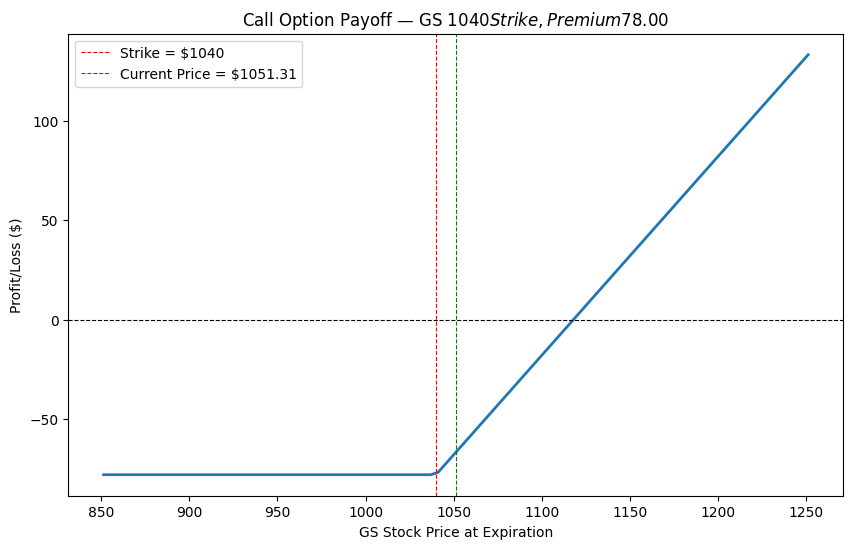

In [20]:
plt.figure(figsize=(10,6))
plt.title(f'Call Option Payoff — GS 1040 Strike, Premium {premium:.2f} Dollars')
plt.plot(possible_stock_prices, payoff, linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.axvline(x=strike, color='red', linestyle='--', linewidth=0.8, label=f'Strike = ${strike}')
plt.axvline(x=current_price, color='green', linestyle='--', linewidth=0.8, label=f'Current Price = ${current_price:.2f}')
plt.xlabel('GS Stock Price at Expiration')
plt.ylabel('Profit/Loss ($)')
plt.title(f'Call Option Payoff — GS $1040 Strike, Premium ${premium:.2f}')
plt.legend()
plt.show()